In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from model_evaluation import *
from model_training import *
import ft_engineering

import pandas as pd
import numpy as np
import carga_datos
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [3]:
import carga_datos
import ft_engineering

In [4]:
import carga_datos

df = carga_datos.cargarDatos()
df.head()

Datos cargados correctamente. Filas: 10763, Columnas: 23


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [6]:
# Columnas
num, cat, ord_ = ft_engineering.get_feature_columns(df)

In [7]:
# Cat a string
df[cat] = df[cat].astype(str)
df[ord_] = df[ord_].astype(str)

In [8]:
# Preprocessor
preprocessor = ft_engineering.build_preprocessor(num, cat, ord_)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categoric', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [9]:
# X/Y
X = df.drop(columns=["Pago_atiempo"] + ft_engineering.EXCLUIR_DE_X)
y = df["Pago_atiempo"]

In [10]:
df[cat] = df[cat].astype(str)
df[ord_] = df[ord_].astype(str)

In [11]:
X = df.drop(columns=["Pago_atiempo"] + ft_engineering.EXCLUIR_DE_X)
y = df["Pago_atiempo"]

In [12]:
X_processed = preprocessor.fit_transform(X)

In [13]:
X_processed = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

X_processed.sample(8)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,...,tendencia_ingresos_82657,tendencia_ingresos_8315,tendencia_ingresos_86286,tendencia_ingresos_9090,tendencia_ingresos_9147,tendencia_ingresos_Creciente,tendencia_ingresos_Decreciente,tendencia_ingresos_Estable,tendencia_ingresos_nan,tipo_credito
1789,3131760.0,6.0,67.0,1380000.0,300000.0,464834.0,95.227787,807.0,6.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2060,2245200.0,6.0,62.0,2320000.0,0.0,337431.0,95.227787,808.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3267,3000000.0,36.0,43.0,3500000.0,340000.0,99664.0,18.050548,729.0,8.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5617,6000000.0,6.0,62.0,4398643.0,3302000.0,898583.0,95.227787,830.0,8.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
10534,1963200.0,6.0,31.0,2200000.0,400000.0,291871.0,95.227787,764.0,4.0,10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
805,1080000.0,6.0,53.0,1000000.0,622000.0,162348.0,95.227787,813.0,5.0,7.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8298,2311080.0,12.0,36.0,5500000.0,3000000.0,160492.0,59.324480,778.0,9.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3791,1168680.0,6.0,49.0,3000000.0,2000000.0,159148.0,95.227787,784.0,9.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0


In [14]:
# Transform
X_processed = preprocessor.fit_transform(X)

X_processed = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

X_processed.sample(8)

,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,...,tendencia_ingresos_82657,tendencia_ingresos_8315,tendencia_ingresos_86286,tendencia_ingresos_9090,tendencia_ingresos_9147,tendencia_ingresos_Creciente,tendencia_ingresos_Decreciente,tendencia_ingresos_Estable,tendencia_ingresos_nan,tipo_credito
2232,2470800.0,12.0,64.0,7000000.0,4000000.0,193875.0,95.227787,874.0,8.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
49,2019600.0,6.0,64.0,3000000.0,1000000.0,299446.0,95.227787,874.0,1.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4249,1889880.0,6.0,52.0,1500000.0,500000.0,281652.0,95.227787,802.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4600,1693200.0,12.0,51.0,1600000.0,600000.0,132694.0,95.227787,735.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
10198,4347000.0,12.0,28.0,3520000.0,249000.0,361755.0,95.227787,707.0,6.0,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2207,2065747.2,12.0,40.0,2300000.0,1000000.0,163280.0,95.227787,748.0,6.0,9.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4045,1394362.8,10.0,37.0,4500000.0,3000000.0,118698.0,95.227787,785.0,9.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0
1305,877538.4,6.0,64.0,3200000.0,1000000.0,130338.0,95.227787,818.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [15]:
# Dataset final
dataset_model = X_processed.copy()
dataset_model["Pago_a_tiempo"] = y.values

In [16]:
# Modelos
result_dict = {}

models = {
    "logistic": LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000
    ),
    "svc": LinearSVC(
        C=1.0,
        max_iter=1000,
        tol=1e-3,
        dual=False,
        class_weight="balanced"
    ),
    "decision_tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42
    ),
    "random_forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=150,
        max_depth=7,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42
    ),
    "xgboost": XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=491 / 1000,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [17]:
# Params
data_params = {
    "name_of_y_col": "Pago_a_tiempo",
    "names_of_x_cols": X_processed.columns.tolist(),
    "dataset": dataset_model
}

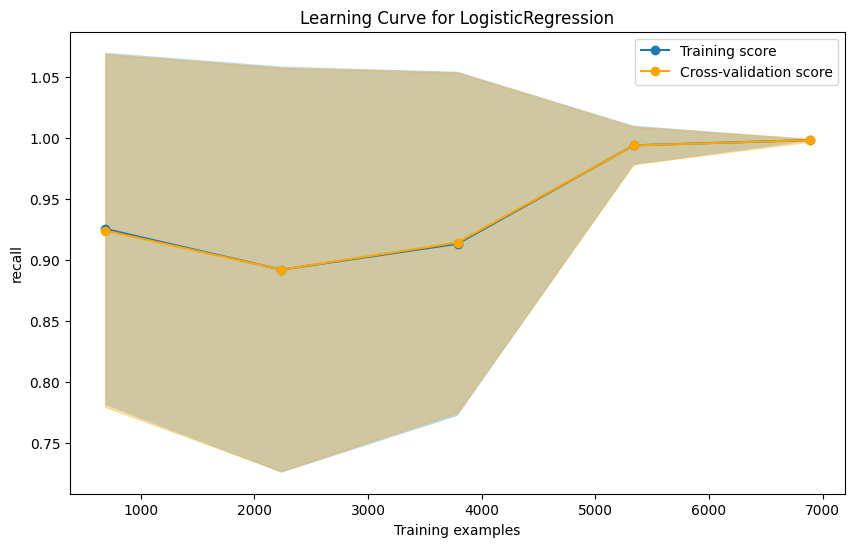

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.9254074  0.89202263 0.91318442 0.99392869 0.99820427]
Training Scores Std: [0.14444201 0.16648551 0.14109785 0.01613392 0.00067428]
Test Scores Mean: [0.92407648 0.89206142 0.9142443  0.99381982 0.99822036]
Test Scores Std: [0.14470102 0.16530599 0.13935877 0.01527192 0.00128859]


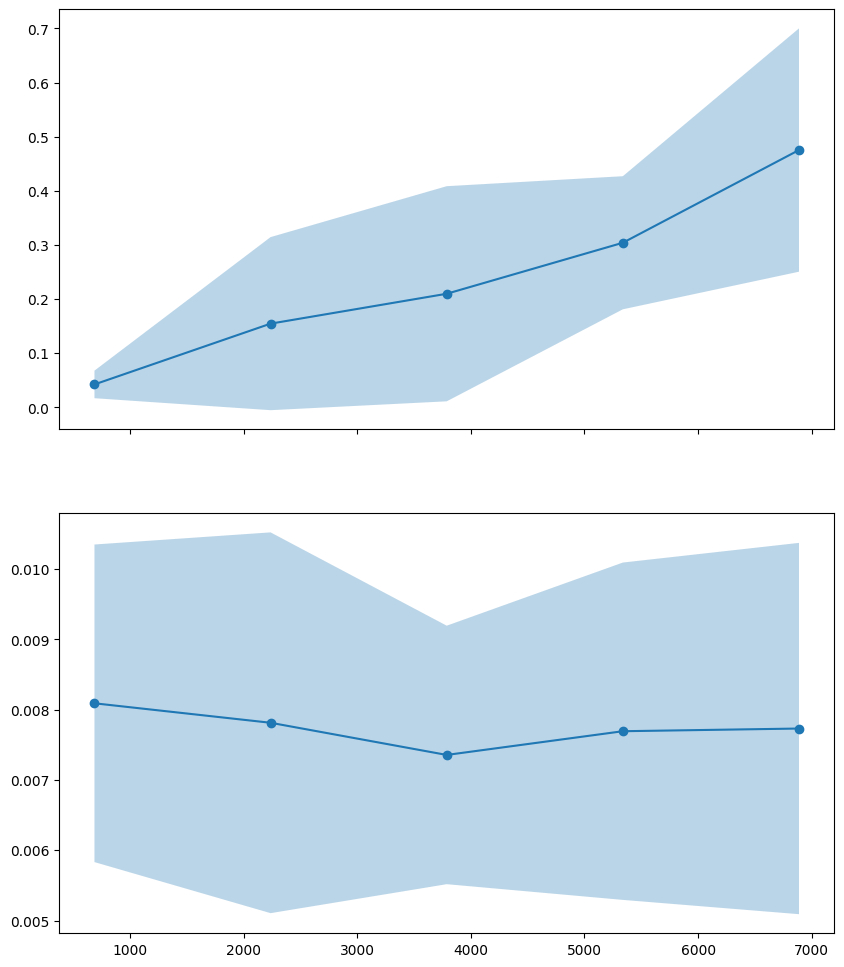

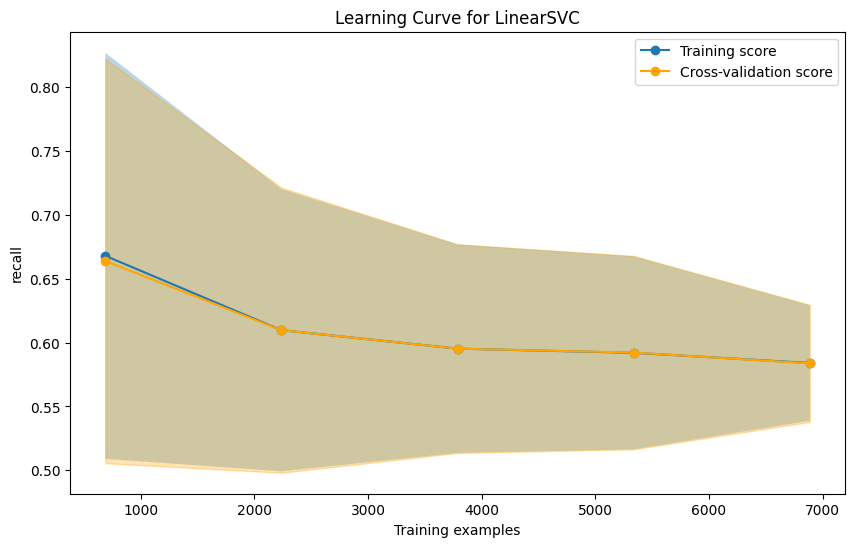

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [0.66796335 0.60972566 0.59526622 0.59198791 0.58403413]
Training Scores Std: [0.15897507 0.11050526 0.08159417 0.07556336 0.04521808]
Test Scores Mean: [0.66391203 0.6097307  0.59525575 0.59218553 0.58371648]
Test Scores Std: [0.15834255 0.11161293 0.08168849 0.07570824 0.04583594]


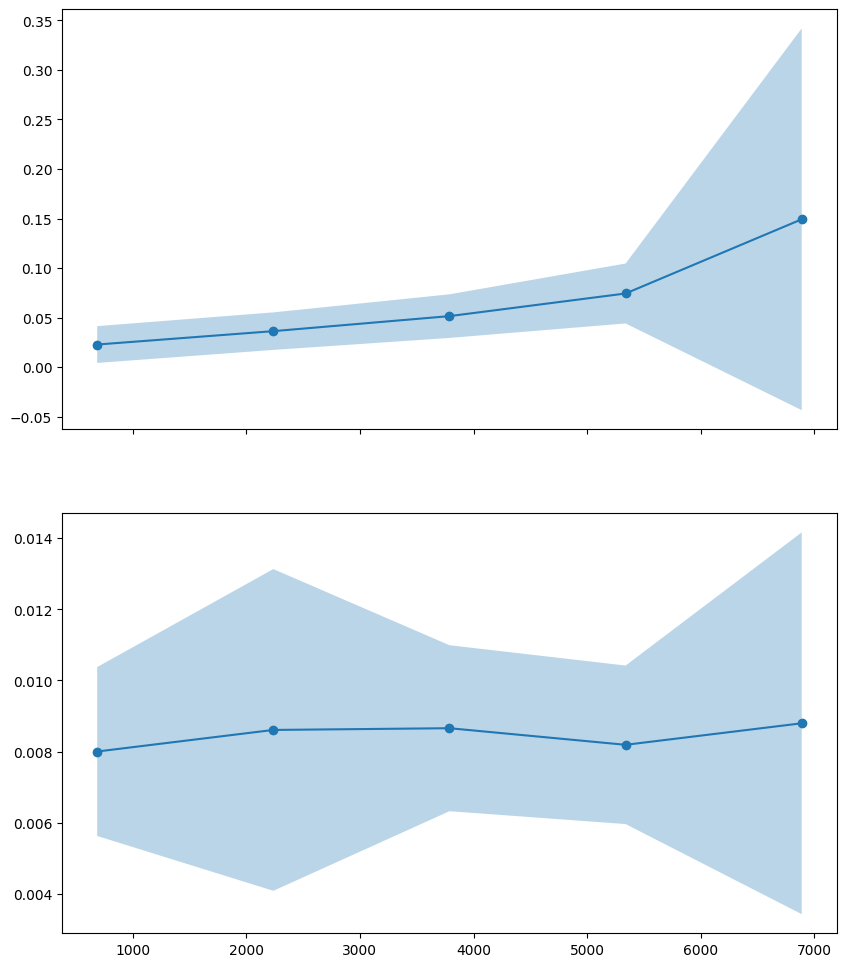

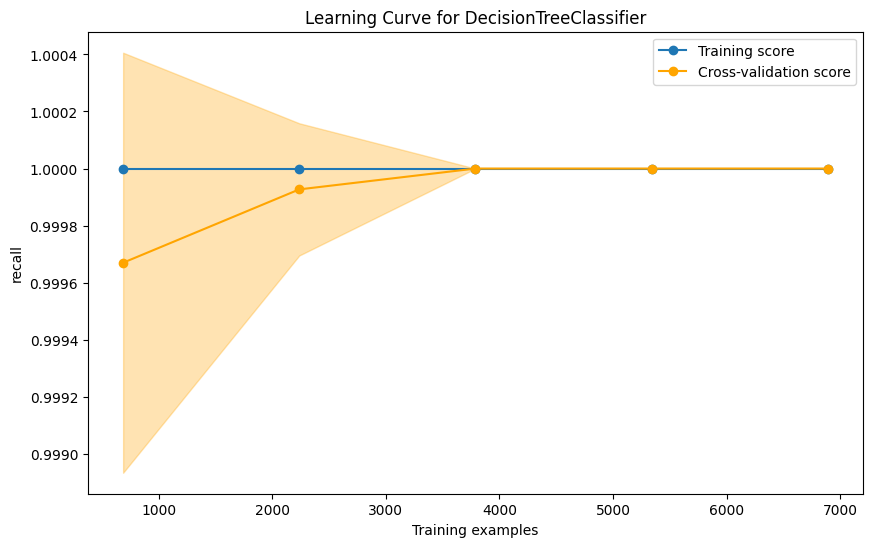

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [1. 1. 1. 1. 1.]
Training Scores Std: [0. 0. 0. 0. 0.]
Test Scores Mean: [0.99966997 0.999927   1.         1.         1.        ]
Test Scores Std: [0.00073601 0.00023167 0.         0.         0.        ]


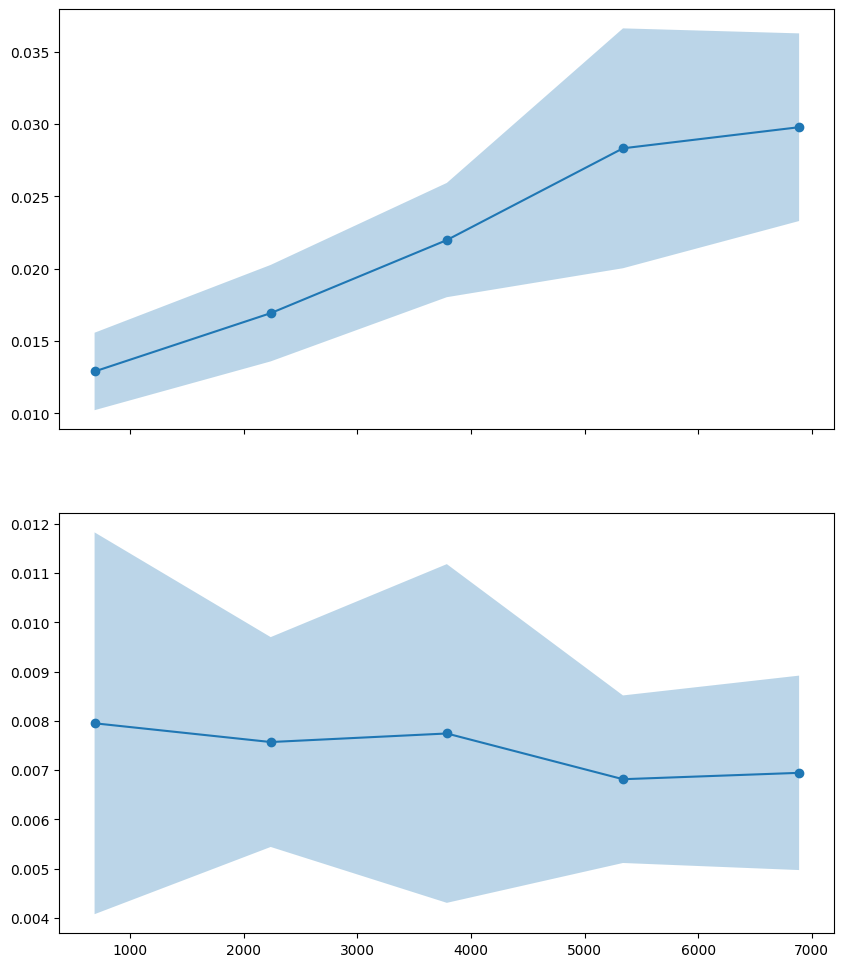

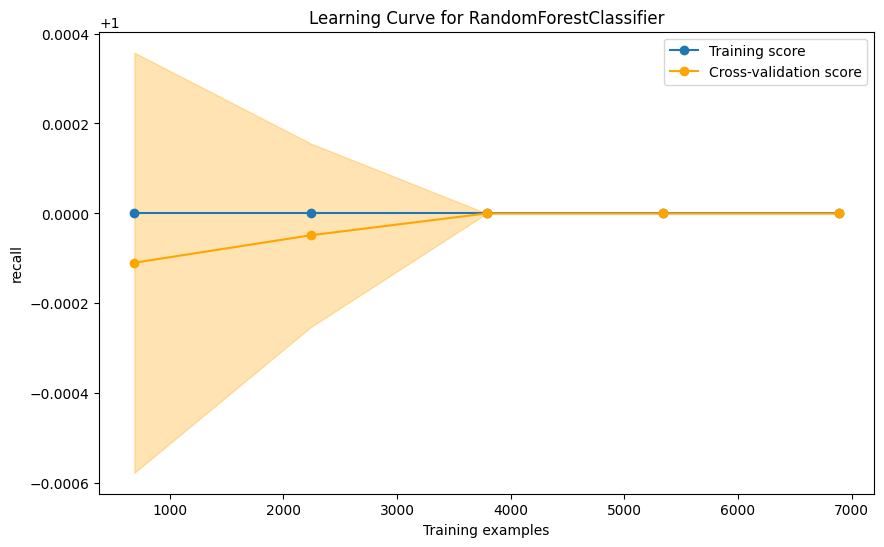

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [1. 1. 1. 1. 1.]
Training Scores Std: [0. 0. 0. 0. 0.]
Test Scores Mean: [0.9998904  0.99995137 1.         1.         1.        ]
Test Scores Std: [0.00046693 0.00020442 0.         0.         0.        ]


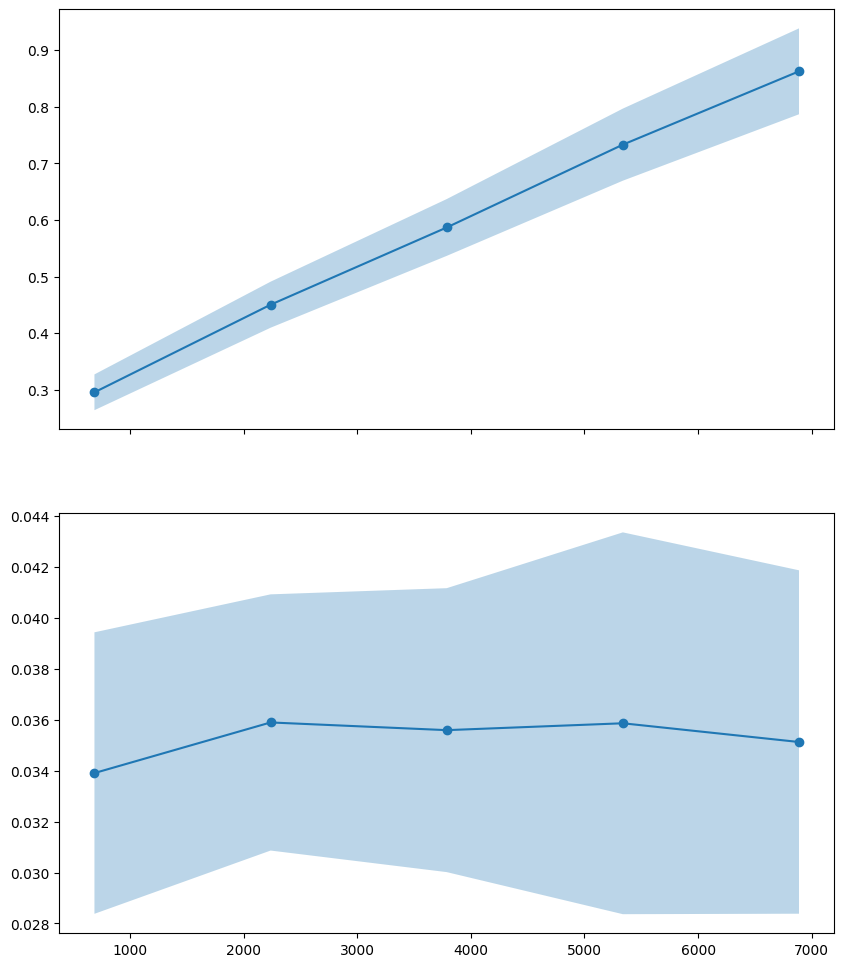

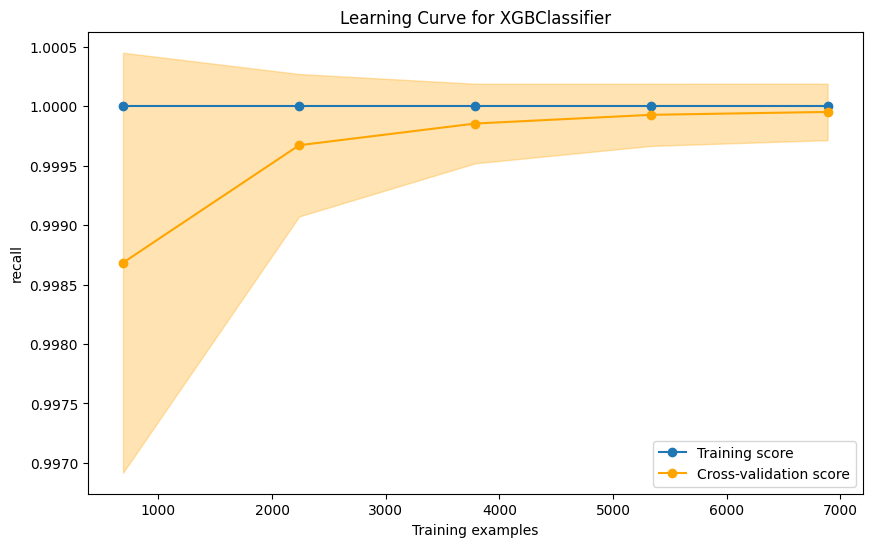

Training Sizes: [ 688 2238 3788 5338 6888]
Training Scores Mean: [1. 1. 1. 1. 1.]
Training Scores Std: [0. 0. 0. 0. 0.]
Test Scores Mean: [0.99868352 0.99967147 0.999854   0.99992713 0.99995154]
Test Scores Std: [0.00176577 0.00059893 0.00033445 0.00026133 0.00023739]


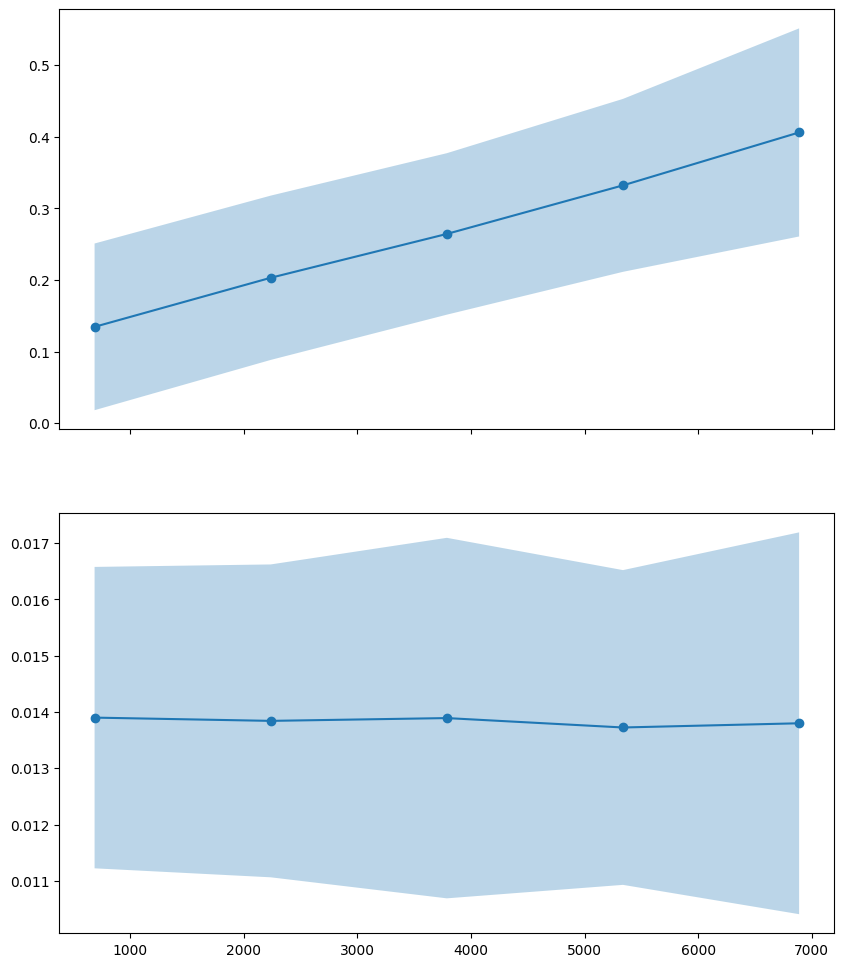

In [18]:
# Train
for model_name, model in models.items():
    result_dict[model_name] = build_model(model, data_params)

In [19]:
# Resultados
records = []

for model_name, model_results in result_dict.items():
    for data_set, metrics in model_results.items():
        for metric_name, score in metrics.items():
            records.append({
                "Model": model_name,
                "Data Set": data_set,
                "Metric": metric_name,
                "Score": score
            })

results_df = pd.DataFrame(records)

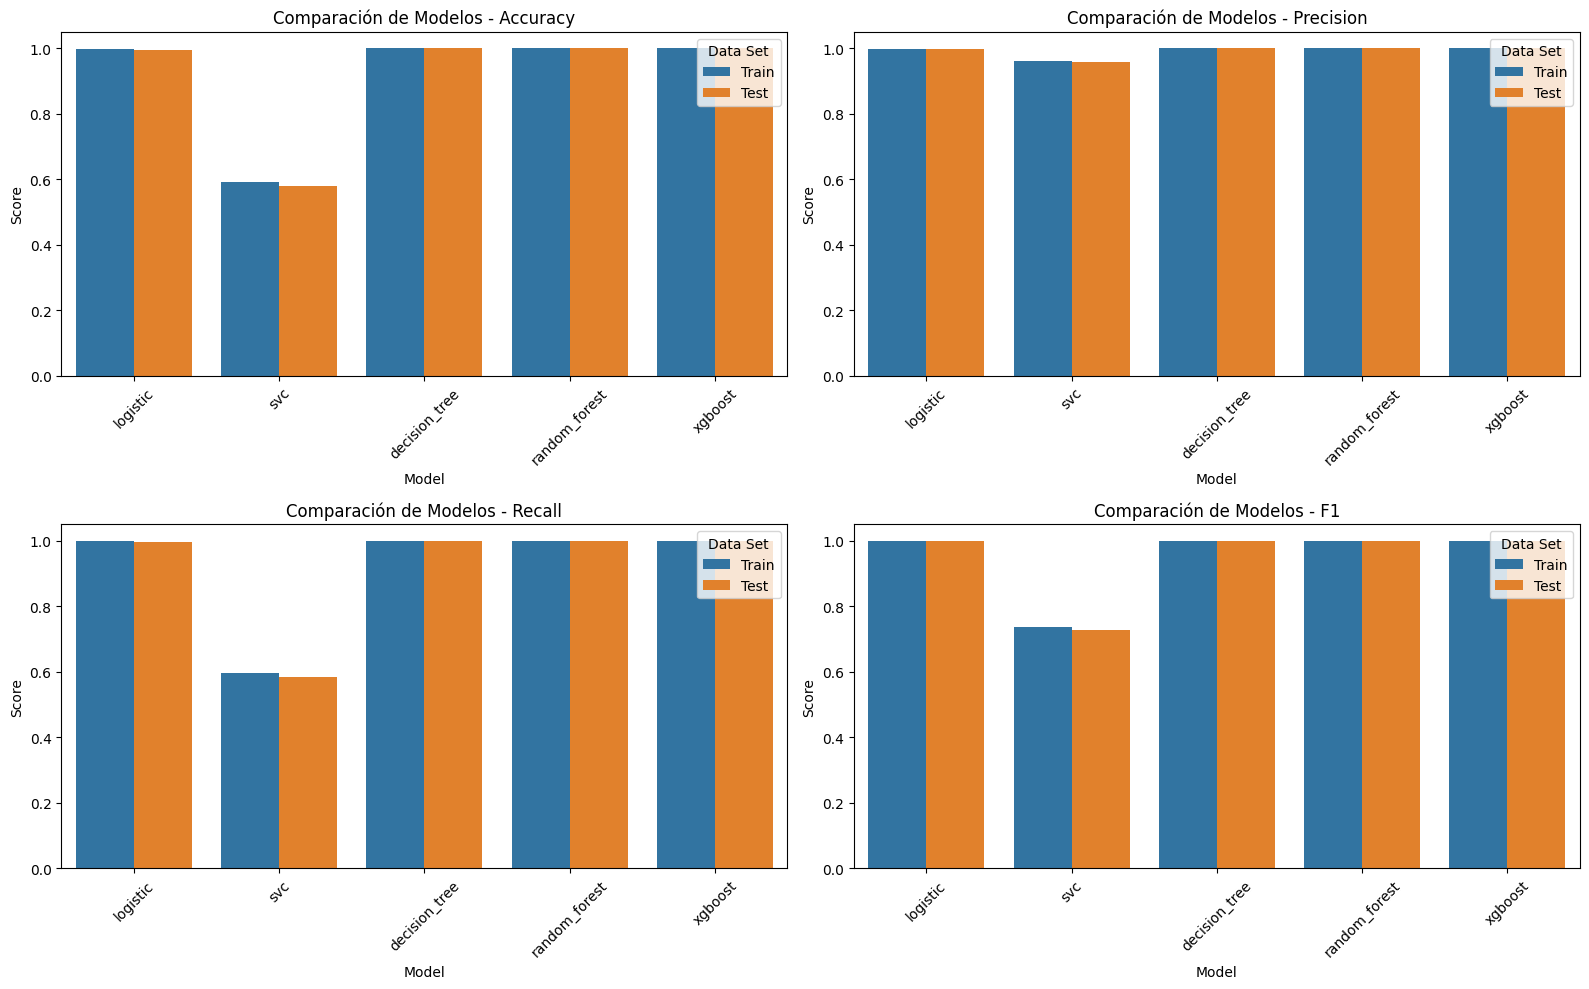

In [20]:
# Gráfico
metrics_to_plot = results_df["Metric"].dropna().unique().tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot[:4]):
    ax = axes[i]
    metric_df = results_df[results_df["Metric"] == metric]

    sns.barplot(
        data=metric_df,
        x="Model",
        y="Score",
        hue="Data Set",
        ax=ax
    )

    ax.set_title(f"Comparación de Modelos - {metric.capitalize()}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()